<a href="https://colab.research.google.com/github/vobritney/ES2245/blob/main/Britney_Vo_ES2245_lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 5: ANOVA and Post-Hoc Analysis of USGS Earthquake Catalogs

**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

**Estimated Time:** 60-75 Minutes


## Objectives
By the end of this lab, you will be able to:
1. Fetch live seismicity data using the USGS ComCat API.
2. Explore and visualize earthquake depths across different tectonic settings.
3. Check the assumptions required for an Analysis of Variance (ANOVA) test.
4. Perform a One-Way ANOVA to test for significant differences between group means.
5. Conduct a Tukey Post-Hoc test to determine exactly *which* tectonic boundaries differ.

## Seismological Context


Earthquake focal depth is strongly controlled by the thermal and rheological properties of the lithosphere. Earthquakes require brittle rock to occur. Depending on the tectonic plate boundary, the depth at which rock becomes too hot and ductile to generate earthquakes changes dramatically.

In this lab, we will analyze the focal depth (in km) of $M > 4.0$ earthquakes from three different real-world tectonic settings:
* **Divergent** (Mid-Atlantic Ridge)
* **Transform** (San Andreas Fault system, California)
* **Convergent** (Japan Trench Subduction Zone)

**Our Research Question:** Is there a statistically significant difference in the mean earthquake depth across these three specific plate boundary regions?

**Null Hypothesis ($H_0$):** $\mu_{Divergent} = \mu_{Transform} = \mu_{Convergent}$ (The mean earthquake depths are equal).  
**Alternative Hypothesis ($H_A$):** At least one tectonic boundary has a different mean earthquake depth.

In [1]:
# Import necessary libraries (Run this cell)
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set plot style
sns.set_theme(style="whitegrid")
print("Libraries successfully imported!")

Libraries successfully imported!


## Task 1: Fetch Live Data from the USGS API
We will write a function to query the USGS API for a specific geographic bounding box, time frame, and minimum magnitude. Then, we will extract the depth of each earthquake from the resulting JSON data.

In [2]:
def fetch_usgs_depths(min_lat, max_lat, min_lon, max_lon, boundary_name):
    """
    Fetches earthquake data from the USGS API and returns a DataFrame of depths.
    """
    # Define our query parameters (M4.0+ between 2018 and 2023)
    url = (
        f"https://earthquake.usgs.gov/fdsnws/event/1/query?"
        f"format=geojson&starttime=2018-01-01&endtime=2023-01-01"
        f"&minmagnitude=4.0"
        f"&minlatitude={min_lat}&maxlatitude={max_lat}"
        f"&minlongitude={min_lon}&maxlongitude={max_lon}"
    )

    print(f"Fetching data for {boundary_name}...")
    response = requests.get(url)

    if response.status_code != 200:
        print("Error fetching data!")
        return pd.DataFrame()

    data = response.json()

    depths = []
    # Loop through the features (earthquakes) in the GeoJSON
    for feature in data['features']:
        # The coordinates array is [longitude, latitude, depth]
        depth = feature['geometry']['coordinates'][2]
        depths.append(depth)

    df = pd.DataFrame({
        'Boundary_Type': boundary_name,
        'Depth_km': depths
    })

    print(f"  -> Found {len(df)} earthquakes.")
    return df

# Let's define our bounding boxes and fetch the data!
# 1. Mid-Atlantic Ridge (Divergent)
df_div = fetch_usgs_depths(-15, 15, -40, -15, 'Divergent')

# 2. California / San Andreas (Transform)
# Note: Lowered magnitude to 3.0 just for California to ensure a large enough sample size for the lab
url_ca = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2018-01-01&endtime=2023-01-01&minmagnitude=3.0&minlatitude=32&maxlatitude=40&minlongitude=-125&maxlongitude=-115"
resp_ca = requests.get(url_ca).json()
df_trans = pd.DataFrame({'Boundary_Type': 'Transform', 'Depth_km': [f['geometry']['coordinates'][2] for f in resp_ca['features']]})
print(f"Fetching data for Transform...\n  -> Found {len(df_trans)} earthquakes.")

# 3. Japan Trench (Convergent)
df_conv = fetch_usgs_depths(30, 45, 135, 150, 'Convergent')

# Combine them all into one main DataFrame
df = pd.concat([df_div, df_trans, df_conv], ignore_index=True)
# Ensure no negative depths (above surface errors)
df['Depth_km'] = df['Depth_km'].clip(lower=0.1)

print("\nData successfully combined into dataframe 'df'!")

Fetching data for Divergent...
  -> Found 277 earthquakes.
Fetching data for Transform...
  -> Found 3070 earthquakes.
Fetching data for Convergent...
  -> Found 3439 earthquakes.

Data successfully combined into dataframe 'df'!


## Task 2: Data Exploration & Visualization
Before running tests, you must understand your data.

**Part A: Summary Statistics**
Use pandas to calculate the mean, median, and standard deviation for each boundary type.

In [5]:
from pandas.core.groupby import groupby
# 1. Display the first 5 rows of the combined dataframe 'df'
# HINT: Use the .head() method on your dataframe
# YOUR CODE HERE:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(df.head(5))


# 2. Group the data by 'Boundary_Type' and calculate the describe() statistics for 'Depth_km'
# HINT: Try df.groupby('ColumnToGroup')['ColumnToCalculate'].describe()
# YOUR CODE HERE:
print(df.groupby('Boundary_Type')['Depth_km'].describe())
df.groupby('Boundary_Type')['Depth_km'].describe().to_csv('output.csv')
df.groupby('Boundary_Type')['Depth_km'].describe().to_excel('output.xlsx')
df.groupby('Boundary_Type')['Depth_km'].describe().to_latex('output.tex')
df.groupby('Boundary_Type')['Depth_km'].describe().to_markdown('output.md')
df.groupby('Boundary_Type')['Depth_km'].describe().to_html('output.html')

  Boundary_Type  Depth_km
0     Divergent      10.0
1     Divergent      10.0
2     Divergent      10.0
3     Divergent      10.0
4     Divergent      10.0
                count       mean        std    min    25%     50%     75%  \
Boundary_Type                                                               
Convergent     3439.0  65.572639  87.040292   2.73  10.00  41.180  64.854   
Divergent       277.0  10.000000   0.000000  10.00  10.00  10.000  10.000   
Transform      3070.0   6.771606   4.108782   0.10   3.82   6.405   8.900   

                  max  
Boundary_Type          
Convergent     507.05  
Divergent       10.00  
Transform       44.62  


**Part B: Boxplot**


Create a boxplot using `seaborn` to visualize the distribution of `Depth_km` for each `Boundary_Type`.

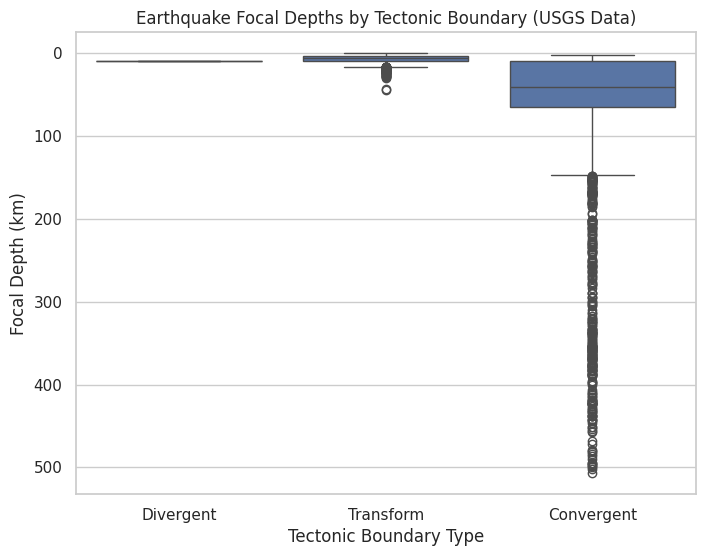

In [6]:
plt.figure(figsize=(8, 6))

# Use sns.boxplot to plot 'Boundary_Type' on the x-axis and 'Depth_km' on the y-axis.
# HINT: sns.boxplot(x='...', y='...', data=...)
# YOUR CODE HERE:
sns.boxplot(x='Boundary_Type', y='Depth_km', data=df)

plt.title('Earthquake Focal Depths by Tectonic Boundary (USGS Data)')
plt.xlabel('Tectonic Boundary Type')
plt.ylabel('Focal Depth (km)')
# Invert y-axis so deeper earthquakes are visually lower on the plot
plt.gca().invert_yaxis()
plt.show()

## Task 3: Checking ANOVA Assumptions
ANOVA relies on two main assumptions:
1.  **Normality:** The data in each group should be approximately normally distributed (Shapiro-Wilk test).
2.  **Homogeneity of Variances:** The variance among the groups should be roughly equal (Levene's test).

**Part A: Data Extraction**
Isolate the depth values into three separate arrays based on their tectonic setting.

In [7]:
# Extract the 'Depth_km' column for each specific group.
# HINT: Use boolean indexing: df[df['Boundary_Type'] == 'BoundaryName']['Depth_km']
# YOUR CODE HERE:

div_depth = df[df['Boundary_Type'] == 'Divergent']['Depth_km']
trans_depth = df[df['Boundary_Type'] == 'Transform']['Depth_km']
conv_depth = df[df['Boundary_Type'] == 'Convergent']['Depth_km']

**Part B: Normality Test**
Use `stats.shapiro()` on each group. The null hypothesis for this test is that the data *is* normally distributed. (A p-value < 0.05 means it is NOT normal).

In [15]:
print("--- Shapiro-Wilk Test ---")

# Pass your extracted arrays into the stats.shapiro() function
# HINT: stat_div, p_div = stats.shapiro(div_depth)
# YOUR CODE HERE:

stat_div, p_div = stats.shapiro(div_depth)
stat_trans, p_trans = stats.shapiro(trans_depth)
stat_conv, p_conv = stats.shapiro(conv_depth)

print(f"Divergent p-value: {p_div:.4f}")
print(f"Transform p-value: {p_trans:.4f}")
print(f"Convergent p-value: {p_conv:.4f}")

--- Shapiro-Wilk Test ---
Divergent p-value: 1.0000
Transform p-value: 0.0000
Convergent p-value: 0.0000


**Question:** Based on the p-values above, do all three of our groups pass the assumption of normality? (Note: Real earthquake depths are often *log-normally* distributed, so failing this test is highly likely in real datasets!)

> **STUDENT ANSWER:** No, only one of the groups, Divergent, passes the assumption of normality. With a value of 1.0 > 0.05.

***

**Part C: Homogeneity of Variance**
Use `stats.levene()` to check if the variances are equal. The null hypothesis is that the variances *are* equal.

In [22]:
print("\n--- Levene's Test ---")

# Pass all three of your arrays into the stats.levene() function
# HINT: stats.levene(group1, group2, group3)
# YOUR CODE HERE:

stat_lev, p_lev = stats.levene(div_depth,trans_depth,conv_depth)

print(f"Levene's test p-value: {p_lev:.4e}")


--- Levene's Test ---
Levene's test p-value: 7.5931e-207


**Question:** Based on Levene's test, do we meet the assumption of equal variances? *(Note: If we fail this in the real world, we would use a Welch's ANOVA or a non-parametric Kruskal-Wallis test. However, we will proceed with the standard ANOVA for the purpose of completing this specific exercise).*

> **STUDENT ANSWER:** No, we reject the null hypothesis, because the values vary too significantly.

## Task 4: The One-Way ANOVA Test
We will now perform the One-Way ANOVA using `stats.f_oneway()`.

In [21]:
# Pass your three arrays into the ANOVA function
# HINT: stats.f_oneway(group1, group2, group3)
# YOUR CODE HERE:

f_statistic, p_value_anova = stats.f_oneway(div_depth,trans_depth,conv_depth)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA p-value: {p_value_anova:.2e}")

ANOVA F-statistic: 755.56
ANOVA p-value: 5.73e-297


**Question:** Based on your p-value, do you reject or fail to reject the Null Hypothesis? What does this mean about the depths of earthquakes across different boundaries?

> **STUDENT ANSWER:** We reject the null hypothesis. This means the depths of the earthquakes are not the same across different boundaries.

## Task 5: Post-Hoc Analysis (Tukey's HSD)
The ANOVA told us that *at least one* boundary is different, but it didn't tell us *which ones*. To find out, we run **Tukey's Honestly Significant Difference (HSD)** test.

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2  meandiff p-adj   lower    upper   reject
-------------------------------------------------------------
Convergent Divergent -55.5726    0.0 -64.6545 -46.4908   True
Convergent Transform  -58.801    0.0 -62.4115 -55.1906   True
 Divergent Transform  -3.2284 0.6846 -12.3508    5.894  False
-------------------------------------------------------------


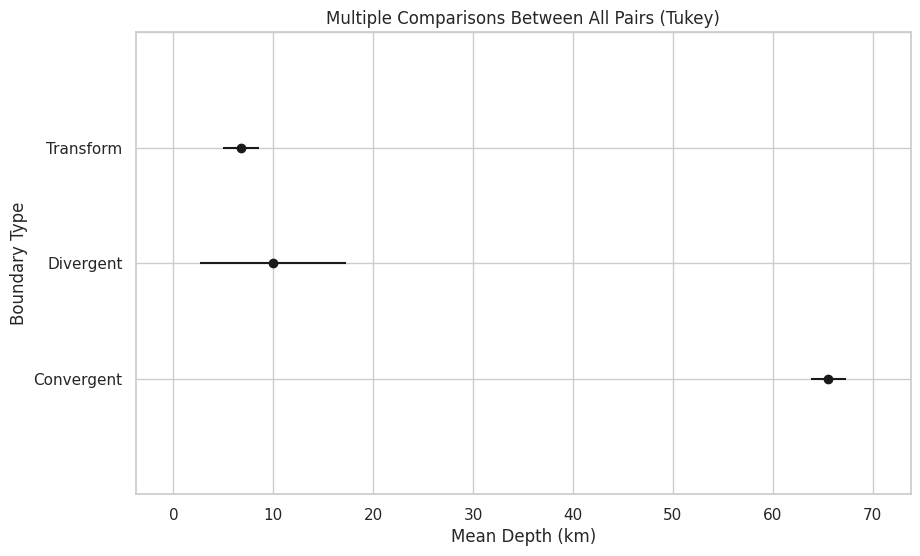

In [23]:
# Run the Tukey HSD test using pairwise_tukeyhsd()
# HINT for endog: Provide the column of continuous data from your main dataframe (df['Depth_km'])
# HINT for groups: Provide the column of categorical data from your main dataframe (df['Boundary_Type'])

# YOUR CODE HERE:
tukey_results = pairwise_tukeyhsd(endog=df['Depth_km'],
                                  groups=df['Boundary_Type'],
                                  alpha=0.05)

print(tukey_results)

# Plot the results
fig = tukey_results.plot_simultaneous(xlabel="Mean Depth (km)", ylabel="Boundary Type")

## Final Lab Questions



**1. Interpret the Tukey HSD Table:** Look at the `reject` column in your Tukey output. Which specific tectonic boundaries have significantly different mean earthquake depths from one another?
> **STUDENT ANSWER:** Divergent Transform


**2. Seismological Interpretation:** Based on the data you pulled directly from the USGS, convergent boundaries have much deeper maximum and mean earthquakes than divergent boundaries. Thinking about the thermal structure of the Earth (the brittle-ductile transition) and the physical process of subduction, why does this make sense?
> **STUDENT ANSWER:** Earthquakes are shallow at divergent boundaries because the separation of the tectonic plates allow magma to push upwards, becoming very pliable instead of earthquake's desirable brittle surface. For subduction zones, the subducting plate is very rigid and cold. It pushes the brittle plate deeper into the mantle before it can heat up enough. Allowing earthquakes to occur deeeep below the surface.